In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [136]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 200)

In [117]:
df = pd.read_excel('Mobiliteitsdata.xlsx').drop('stad', axis=1)

df.replace({'geslacht': {'anders': np.nan}}, inplace=True)

df = df.dropna()

In [118]:
df.head()

,persoon_ID,geslacht,leeftijd,gewicht_KG,burgerlijke_staat,jaarsalaris_eu,huishouden_grootte,provincie,opleiding_niveau,autobezit,...,elektrisch_auto,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG
0,811069,man,50,52.66,weduwe/weduwnaar,48003.64,5,Flevoland,MBO,ja,...,nee,13266.05,2040.54,3227.95,480.71,4,1,20,Nooit,7591.93
1,246882,vrouw,65,64.58,samenwonend,55208.63,2,Overijssel,WO,ja,...,nee,15229.89,0.00,2298.96,1423.34,5,0,7,Heel soms,8742.25
2,978385,man,49,90.87,samenwonend,29533.78,2,Utrecht,HBO,ja,...,ja,19853.24,1540.46,4504.21,632.48,4,1,2,Altijd,4513.56
3,120468,man,34,80.43,gehuwd,44453.27,2,Utrecht,HBO,ja,...,nee,9935.50,1825.92,4407.56,1266.84,3,2,21,Heel soms,6904.41
4,637034,man,60,72.28,ongehuwd,56497.64,2,Gelderland,MBO,ja,...,ja,16266.67,1851.07,1936.12,1676.00,0,5,0,Nooit,4420.80


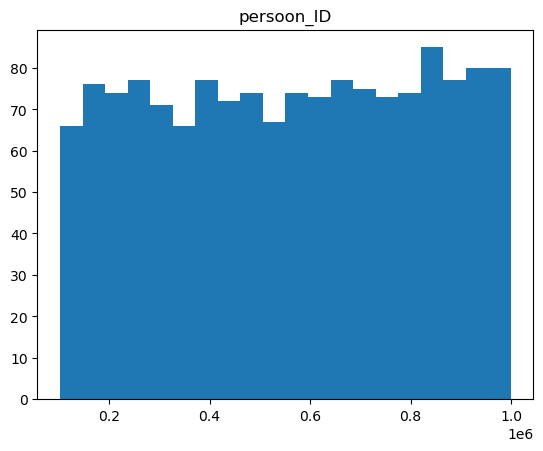

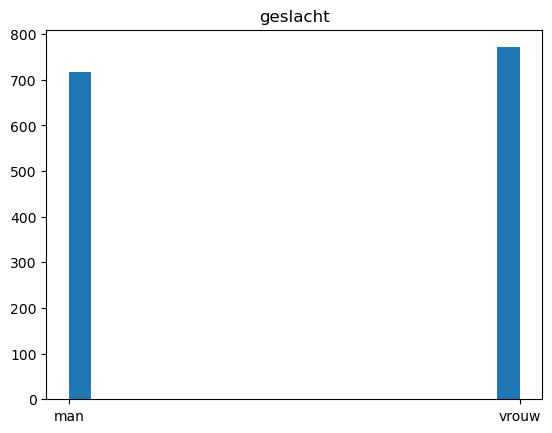

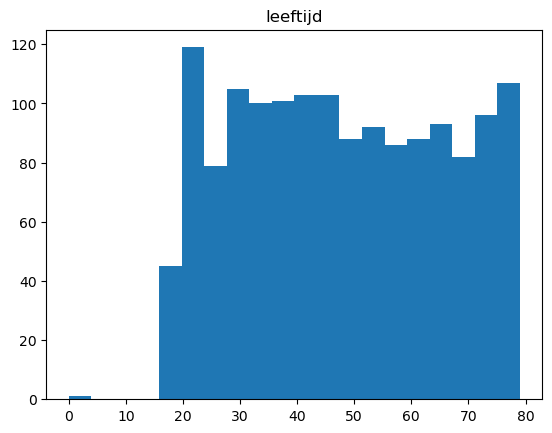

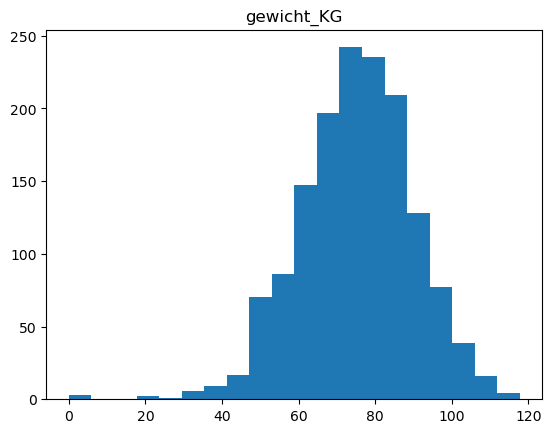

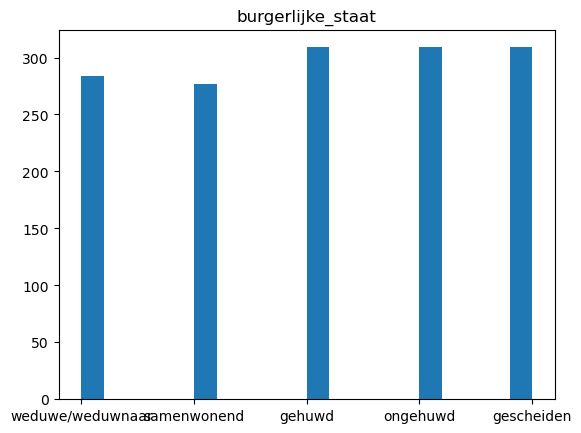

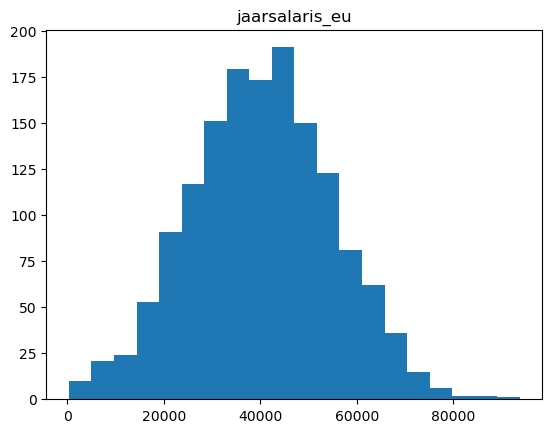

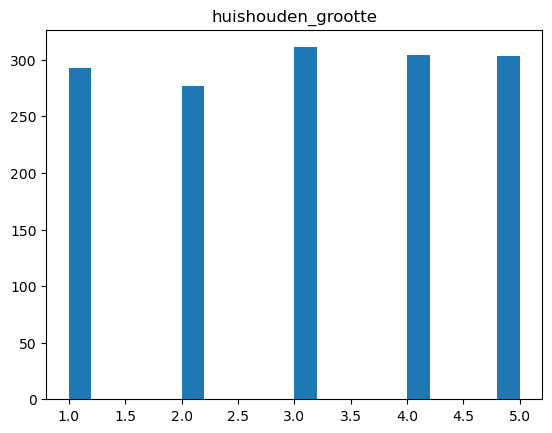

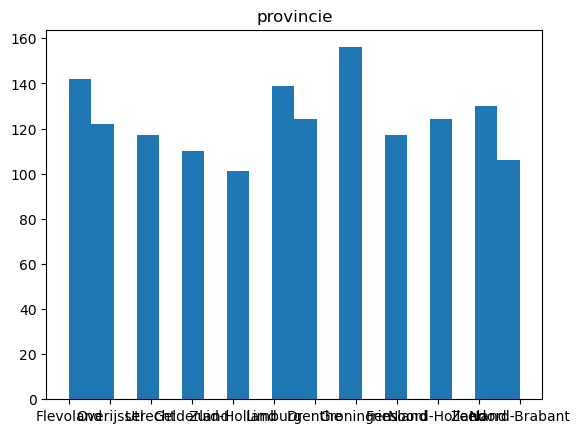

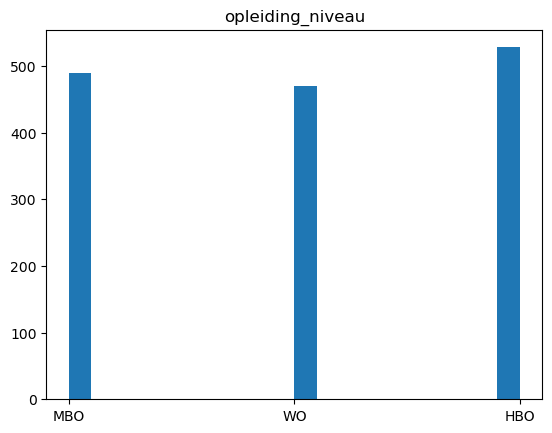

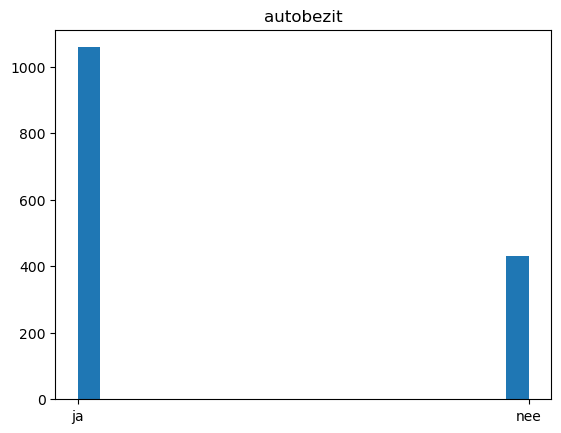

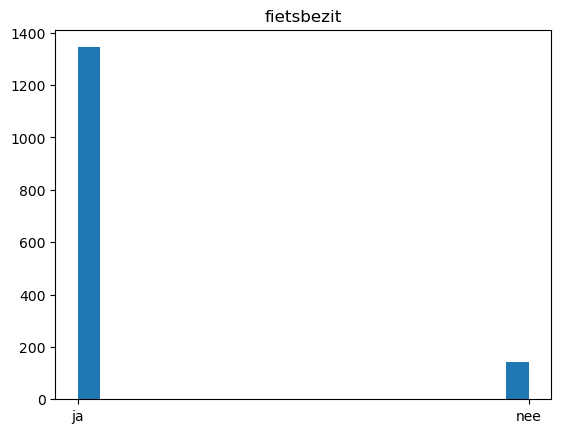

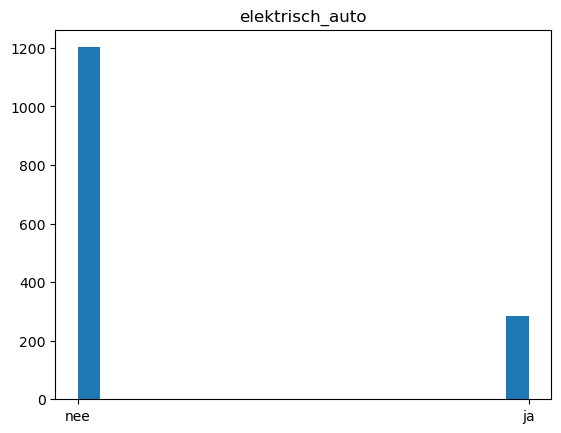

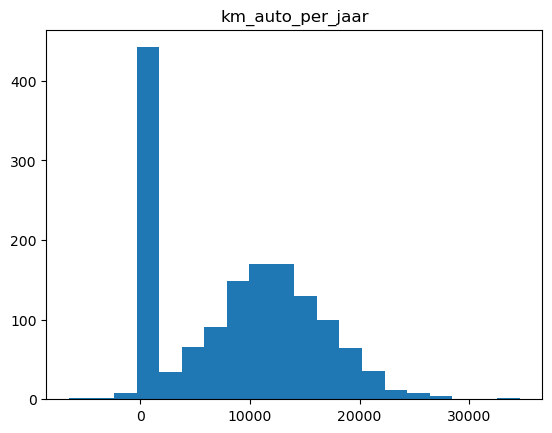

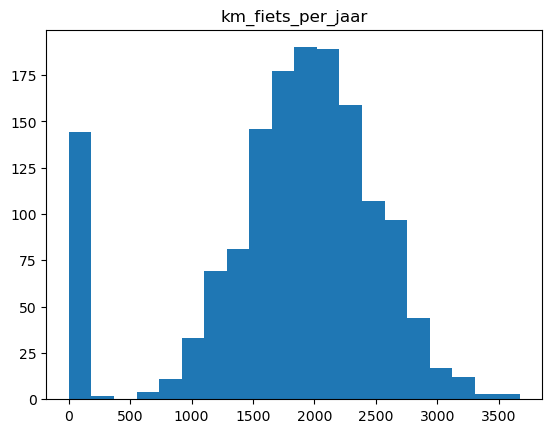

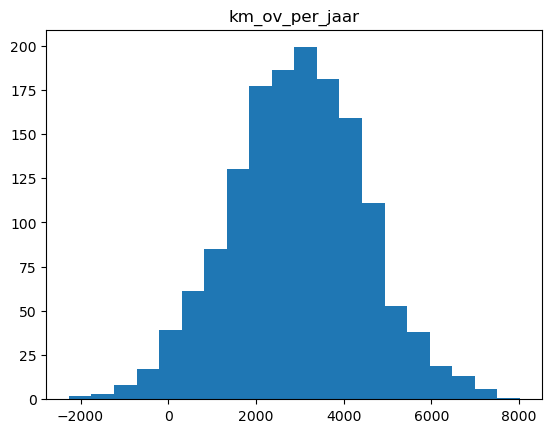

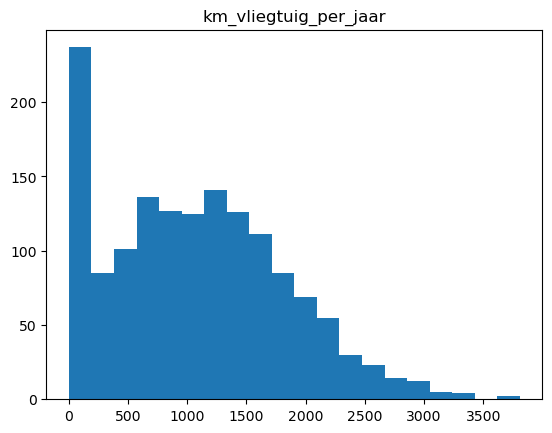

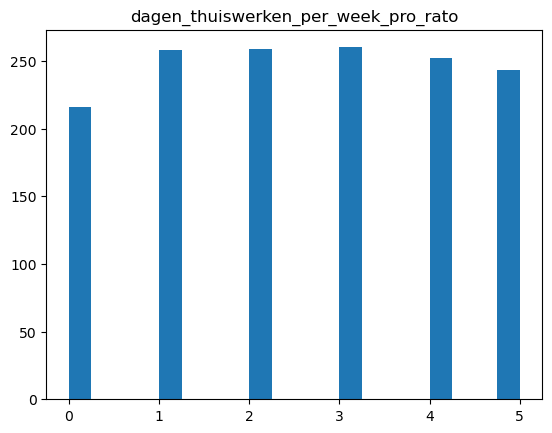

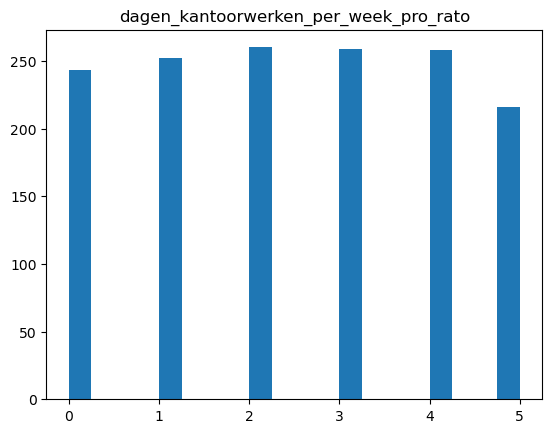

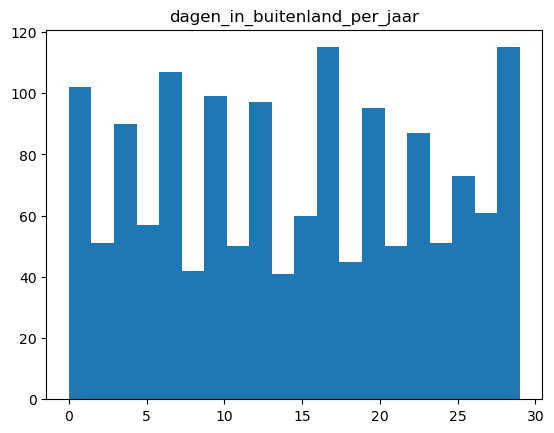

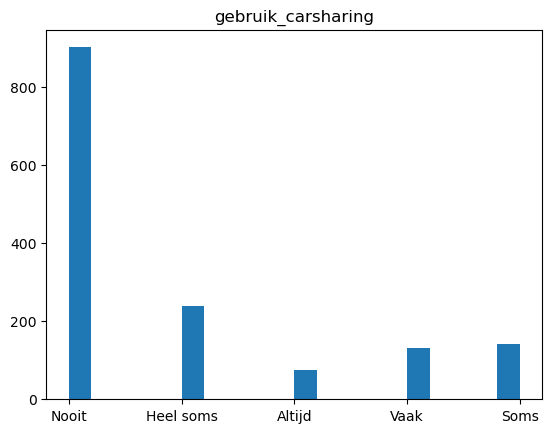

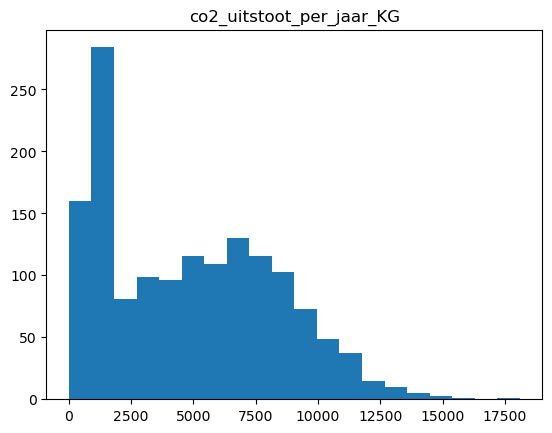

In [119]:
for i in df.columns:
    plt.hist(df[i], bins=20)
    plt.title(i)
    plt.show()

Ordinale categorieen

In [120]:
mapdict = {'gebruik_carsharing':{'Nooit': 1, 'Heel soms': 2, 'Soms': 3, 'Vaak': 4, 'Altijd': 5},
           'opleiding_niveau':{'MBO': 1, 'HBO': 2, 'WO': 3},}

df = df.replace(mapdict)

C:\Users\schur\AppData\Local\Temp\ipykernel_33584\1283501653.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapdict)


Nominale kolommen

In [121]:
binairy_cols = ['autobezit', 'fietsbezit', 'elektrisch_auto', 'geslacht', 'provincie', 'burgerlijke_staat']
df = pd.get_dummies(df, columns=binairy_cols, drop_first=True)

In [122]:
df.head()


,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,opleiding_niveau,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,...,provincie_Noord-Brabant,provincie_Noord-Holland,provincie_Overijssel,provincie_Utrecht,provincie_Zeeland,provincie_Zuid-Holland,burgerlijke_staat_gescheiden,burgerlijke_staat_ongehuwd,burgerlijke_staat_samenwonend,burgerlijke_staat_weduwe/weduwnaar
0,811069,50,52.66,48003.64,5,1,13266.05,2040.54,3227.95,480.71,...,False,False,False,False,False,False,False,False,False,True
1,246882,65,64.58,55208.63,2,3,15229.89,0.00,2298.96,1423.34,...,False,False,True,False,False,False,False,False,True,False
2,978385,49,90.87,29533.78,2,2,19853.24,1540.46,4504.21,632.48,...,False,False,False,True,False,False,False,False,True,False
3,120468,34,80.43,44453.27,2,2,9935.50,1825.92,4407.56,1266.84,...,False,False,False,True,False,False,False,False,False,False
4,637034,60,72.28,56497.64,2,1,16266.67,1851.07,1936.12,1676.00,...,False,False,False,False,False,False,False,True,False,False


In [137]:
corr = df.corr()


corr.where(corr.abs() >= 0.6)

,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,opleiding_niveau,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG,autobezit_nee,fietsbezit_nee,elektrisch_auto_nee,geslacht_vrouw,provincie_Flevoland,provincie_Friesland,provincie_Gelderland,provincie_Groningen,provincie_Limburg,provincie_Noord-Brabant,provincie_Noord-Holland,provincie_Overijssel,provincie_Utrecht,provincie_Zeeland,provincie_Zuid-Holland,burgerlijke_staat_gescheiden,burgerlijke_staat_ongehuwd,burgerlijke_staat_samenwonend,burgerlijke_staat_weduwe/weduwnaar
persoon_ID,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
leeftijd,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gewicht_KG,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jaarsalaris_eu,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
huishouden_grootte,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
opleiding_niveau,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
km_auto_per_jaar,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.915065,-0.780356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
km_fiets_per_jaar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.776495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
km_ov_per_jaar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
km_vliegtuig_per_jaar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
